## Step 1 — Check Kaggle GPU

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Number of GPUs:", torch.cuda.device_count())

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Number of GPUs: 2


## Step 2 — Install required packages

In [2]:
!pip install -q -U \
    transformers \
    datasets \
    accelerate \
    peft \
    evaluate \
    rouge_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 41.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 54.4 MB/s eta 0:00:00a 0:00:01


## Step 3 — Load IU X-Ray

In [3]:
from datasets import load_dataset

dataset = load_dataset("CAIR-M3LLM/IU-Xray")

print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/379M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/382M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/109M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2069 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/590 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/296 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['images', 'messages', 'id', 'extra_info'],
        num_rows: 2069
    })
    test: Dataset({
        features: ['images', 'messages', 'id', 'extra_info'],
        num_rows: 590
    })
    validation: Dataset({
        features: ['images', 'messages', 'id', 'extra_info'],
        num_rows: 296
    })
})


## Step 4 — Inspect one sample

In [4]:
sample = dataset["train"][0]

print("ID:", sample["id"])
print("Number of images:", len(sample["images"]))
print("\nMessages:")
print(sample["messages"])

print("\nExtra info:")
print(sample["extra_info"])

ID: IU-Xray/00000000
Number of images: 2

Messages:
[{'role': 'user', 'content': '<image><image>Please review the chest X-ray image and create a report that assesses any abnormalities, including potential signs of old empyema, fractures, or other abnormalities in the thoracic cavity.'}, {'role': 'assistant', 'content': 'The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.'}]

Extra info:



## Step 5 — Display the X-rays + report

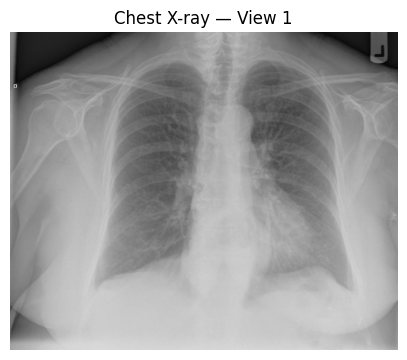

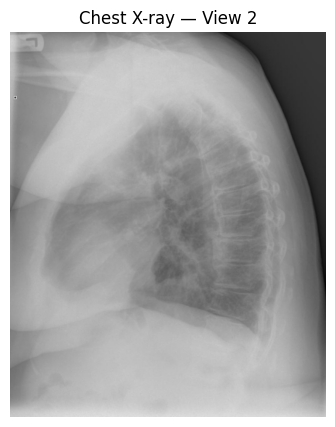

Ground-truth report:
The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.


In [5]:
import matplotlib.pyplot as plt

sample = dataset["train"][0]

for i, img in enumerate(sample["images"]):
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap="gray")
    plt.title(f"Chest X-ray — View {i+1}")
    plt.axis("off")
    plt.show()

print("Ground-truth report:")
print(sample["messages"][1]["content"])

## Step 6 — Choose our VLM

In [6]:
import transformers

print("Transformers version:", transformers.__version__)

Transformers version: 5.17.0


## Step 7 — Load Qwen2.5-VL processor + model

In [7]:
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

processor = AutoProcessor.from_pretrained(model_name)

print("Processor loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Processor loaded successfully.


## Step 8 — Load VLM(Qwen2.5-VL-3B) Model

In [8]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model loaded successfully.")
print("Model device:", model.device)

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded successfully.
Model device: cuda:0


## Step 9 — Test VLM Before Fine-Tuning

In [9]:
sample = dataset["test"][0]
images = sample["images"]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "image"},
            {
                "type": "text",
                "text": "Review these chest X-rays and provide a concise radiology report."
            }
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=images,
    return_tensors="pt",
    padding=True
).to(model.device)

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=150
    )

generated_trimmed = generated_ids[:, inputs.input_ids.shape[1]:]
report = processor.batch_decode(
    generated_trimmed,
    skip_special_tokens=True
)[0]

print("BASE MODEL REPORT:")
print(report)

print("\nGROUND-TRUTH REPORT:")
print(sample["messages"][1]["content"])

BASE MODEL REPORT:
**Radiology Report: Chest X-ray**

- **Patient:** [Patient Name]
- **Date:** [Date of Imaging]
- **Position:** Posteroanterior (PA) view

**Description:**
The posteroanterior (PA) chest X-ray shows the following:

1. **Lungs:**
   - Bilateral lungs appear clear with no signs of consolidation, infiltrates, or masses.
   - The lung fields show normal vascular markings without evidence of significant pulmonary edema.

2. **Heart:**
   - Cardiac silhouette is within normal limits with no cardiomegaly or pericardial effusion noted.

3. **Diaphragm:**
   - Both diaphragms are present and appear to

GROUND-TRUTH REPORT:
Normal cardiomediastinal silhouette. There is no focal consolidation. There are no XXXX of a large pleural effusion. There is no pneumothorax. There is no acute bony abnormality seen.


## Step 10 - Save Baseline Exmaples 

In [10]:
baseline_example = {
    "id": sample["id"],
    "base_report": report,
    "ground_truth": sample["messages"][1]["content"]
}

print("Baseline example saved:", baseline_example["id"])

Baseline example saved: IU-Xray/00000000


## Step 11 — Prepare Dataset for Fine-Tuning

In [11]:
train_sample = dataset["train"][0]

print("Number of images:", len(train_sample["images"]))
print("\nUSER:")
print(train_sample["messages"][0]["content"])

print("\nTARGET REPORT:")
print(train_sample["messages"][1]["content"])

Number of images: 2

USER:
<image><image>Please review the chest X-ray image and create a report that assesses any abnormalities, including potential signs of old empyema, fractures, or other abnormalities in the thoracic cavity.

TARGET REPORT:
The heart size and pulmonary vascularity appear within normal limits. A large hiatal hernia is noted. The lungs are free of focal airspace disease. No pneumothorax or pleural effusion is seen. Degenerative changes are present in the spine.


## Step 12 — Install LoRA Training Support

In [12]:
import peft

print("PEFT version:", peft.__version__)

PEFT version: 0.21.0


In [13]:
!pip install -q -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 34.8 MB/s eta 0:00:00a 0:00:01


## Step 13 — Configure LoRA

In [14]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


trainable params: 7,372,800 || all params: 3,761,995,776 || trainable%: 0.1960


## Step 14 — Enable Training Settings

In [15]:
model.config.use_cache = False
model.enable_input_require_grads()

print("Training mode prepared.")

Training mode prepared.


## Step 15 — Create Training Batch Function

In [16]:
def collate_fn(examples):
    texts = []
    images = []

    for example in examples:
        report = example["messages"][1]["content"]

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "image"},
                    {
                        "type": "text",
                        "text": "Review these chest X-rays and provide a concise radiology report."
                    }
                ]
            },
            {
                "role": "assistant",
                "content": report
            }
        ]

        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )

        texts.append(text)
        images.append(example["images"])

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt"
    )

    batch["labels"] = batch["input_ids"].clone()
    batch["labels"][batch["attention_mask"] == 0] = -100

    return batch

print("Training batch function created.")

Training batch function created.


## Step 16 — Test Training Batch

In [17]:
test_batch = collate_fn([
    dataset["train"][0],
    dataset["train"][1]
])

print("Input IDs:", test_batch["input_ids"].shape)
print("Attention mask:", test_batch["attention_mask"].shape)
print("Labels:", test_batch["labels"].shape)
print("Pixel values:", test_batch["pixel_values"].shape)

print("\nBatch test successful.")

Input IDs: torch.Size([2, 757])
Attention mask: torch.Size([2, 757])
Labels: torch.Size([2, 757])
Pixel values: torch.Size([5400, 1176])

Batch test successful.


## Step 17 — Mask Non-Report Tokens

In [18]:
def collate_fn(examples):
    texts = []
    images = []

    for example in examples:
        report = example["messages"][1]["content"]

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "image"},
                    {
                        "type": "text",
                        "text": "Review these chest X-rays and provide a concise radiology report."
                    }
                ]
            },
            {
                "role": "assistant",
                "content": report
            }
        ]

        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False
        )

        texts.append(text)
        images.append(example["images"])

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt"
    )

    labels = batch["input_ids"].clone()

    # Ignore padding
    labels[batch["attention_mask"] == 0] = -100

    # Ignore image tokens
    image_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
    labels[labels == image_token_id] = -100

    batch["labels"] = labels
    return batch

print("Training batch function updated.")

Training batch function updated.


## Step 18 — Configure Training

In [19]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="/kaggle/working/qwen25vl-iu-xray",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    save_strategy="epoch",
    report_to="none",
    remove_unused_columns=False,
    gradient_checkpointing=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    data_collator=collate_fn
)

print("Trainer configured successfully.")

Trainer configured successfully.


## Step 19 — Final Training Check

In [20]:
print("Training samples:", len(trainer.train_dataset))

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")
print(f"Trainable percentage: {100 * trainable / total:.4f}%")

Training samples: 2069
Trainable parameters: 7,372,800
Total parameters: 3,761,995,776
Trainable percentage: 0.1960%


## Step 20 — LoRA Fine-Tuning of Qwen2.5-VL

In [21]:
train_result = trainer.train()

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
20,3.014825
40,1.542348
60,1.351211
80,1.273471
100,1.220063
120,1.141099
140,1.139568
160,1.145503
180,1.120369
200,1.138322


## Step 21 — Save LoRA Fine-Tuned Model

In [22]:
save_path = "/kaggle/working/qwen25vl-iu-xray-lora"

model.save_pretrained(save_path)
processor.save_pretrained(save_path)

print("LoRA model saved successfully.")

LoRA model saved successfully.


## Step 22 — Fine-Tuned Model Inference

In [24]:
model.eval()
model.config.use_cache = True

sample = dataset["test"][0]
images = sample["images"]

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "image"},
            {
                "type": "text",
                "text": "Review these chest X-rays and provide a concise radiology report."
            }
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=images,
    return_tensors="pt",
    padding=True
).to(model.device)

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=150
    )

generated_trimmed = generated_ids[:, inputs.input_ids.shape[1]:]

finetuned_report = processor.batch_decode(
    generated_trimmed,
    skip_special_tokens=True
)[0]

print("FINE-TUNED MODEL REPORT:")
print(finetuned_report)

print("\nGROUND-TRUTH REPORT:")
print(sample["messages"][1]["content"])

FINE-TUNED MODEL REPORT:
The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.

GROUND-TRUTH REPORT:
Normal cardiomediastinal silhouette. There is no focal consolidation. There are no XXXX of a large pleural effusion. There is no pneumothorax. There is no acute bony abnormality seen.


## Step 23 — Compare Baseline vs Fine-Tuned Output

In [25]:
print("BASE MODEL:")
print(baseline_example["base_report"])

print("\nFINE-TUNED MODEL:")
print(finetuned_report)

print("\nGROUND TRUTH:")
print(sample["messages"][1]["content"])

BASE MODEL:
**Radiology Report: Chest X-ray**

- **Patient:** [Patient Name]
- **Date:** [Date of Imaging]
- **Position:** Posteroanterior (PA) view

**Description:**
The posteroanterior (PA) chest X-ray shows the following:

1. **Lungs:**
   - Bilateral lungs appear clear with no signs of consolidation, infiltrates, or masses.
   - The lung fields show normal vascular markings without evidence of significant pulmonary edema.

2. **Heart:**
   - Cardiac silhouette is within normal limits with no cardiomegaly or pericardial effusion noted.

3. **Diaphragm:**
   - Both diaphragms are present and appear to

FINE-TUNED MODEL:
The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.

GROUND TRUTH:
Normal cardiomediastinal silhouette. There is no focal consolidation. There are no XXXX of a large pleural effusion. There is no pneumothorax. There is no acute bony abnormality seen.


## Step 24 — Generate Fine-Tuned Reports on Full Test Set

In [26]:
from tqdm.auto import tqdm
import pandas as pd
import torch

results = []

model.eval()
model.config.use_cache = True

for sample in tqdm(dataset["test"], desc="Generating test reports"):
    
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "image"},
                {
                    "type": "text",
                    "text": "Review these chest X-rays and provide a concise radiology report."
                }
            ],
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=sample["images"],
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=150,
            do_sample=False
        )

    generated_trimmed = generated_ids[:, inputs.input_ids.shape[1]:]

    prediction = processor.batch_decode(
        generated_trimmed,
        skip_special_tokens=True
    )[0].strip()

    results.append({
        "id": sample["id"],
        "ground_truth": sample["messages"][1]["content"],
        "fine_tuned_report": prediction
    })

results_df = pd.DataFrame(results)

results_df.to_csv(
    "/kaggle/working/fine_tuned_test_predictions.csv",
    index=False
)

print("Test reports generated:", len(results_df))
print("Predictions saved successfully.")

Generating test reports:   0%|          | 0/590 [00:00<?, ?it/s]

Test reports generated: 590
Predictions saved successfully.


## Step 25 — Calculate Report Generation Metrics

In [27]:
import evaluate
import numpy as np

bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

predictions = results_df["fine_tuned_report"].tolist()
references = results_df["ground_truth"].tolist()

# BLEU
bleu_result = bleu.compute(
    predictions=predictions,
    references=[[ref] for ref in references]
)

# ROUGE
rouge_result = rouge.compute(
    predictions=predictions,
    references=references
)

print(f"BLEU:    {bleu_result['bleu']:.4f}")
print(f"ROUGE-1: {rouge_result['rouge1']:.4f}")
print(f"ROUGE-2: {rouge_result['rouge2']:.4f}")
print(f"ROUGE-L: {rouge_result['rougeL']:.4f}")

BLEU:    0.1193
ROUGE-1: 0.4252
ROUGE-2: 0.1756
ROUGE-L: 0.3163


## Step 26 — Calculate Per-Case ROUGE-L Scores

In [28]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

case_scores = []

for pred, ref in zip(
    results_df["fine_tuned_report"],
    results_df["ground_truth"]
):
    score = scorer.score(ref, pred)["rougeL"].fmeasure
    case_scores.append(score)

results_df["rougeL"] = case_scores

print(results_df["rougeL"].describe())

results_df.to_csv(
    "/kaggle/working/fine_tuned_test_predictions_scored.csv",
    index=False
)

print("\nPer-case scores saved successfully.")

count    590.000000
mean       0.320470
std        0.145313
min        0.000000
25%        0.222222
50%        0.306624
75%        0.376812
max        1.000000
Name: rougeL, dtype: float64

Per-case scores saved successfully.


## Step 27 — Select Top 10 Prediction Cases

In [29]:
top10 = results_df.nlargest(10, "rougeL").copy()

print(
    top10[
        ["id", "rougeL", "ground_truth", "fine_tuned_report"]
    ].to_string(index=False)
)

              id   rougeL                                                                                                                                 ground_truth                                                                                                                                        fine_tuned_report
IU-Xray/00000036 1.000000                                                           The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.                                                                       The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.
IU-Xray/00000083 1.000000                                                           The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.                                                                       The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.
IU-Xray/00000405 0.933333 The lungs are 

In [31]:
import os
import matplotlib.pyplot as plt
import textwrap

output_dir = "/kaggle/working/top10_vlm_results"
os.makedirs(output_dir, exist_ok=True)

# Map IDs to test-set samples
test_lookup = {sample["id"]: sample for sample in dataset["test"]}

for rank, (_, row) in enumerate(top10.iterrows(), start=1):
    
    sample = test_lookup[row["id"]]
    imgs = sample["images"]

    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[3, 1.5]
    )

    # X-ray view 1
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(imgs[0], cmap="gray")
    ax1.set_title("Chest X-ray — View 1", fontsize=14)
    ax1.axis("off")

    # X-ray view 2
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(imgs[1], cmap="gray")
    ax2.set_title("Chest X-ray — View 2", fontsize=14)
    ax2.axis("off")

    # Reports
    ax3 = fig.add_subplot(gs[1, :])
    ax3.axis("off")

    gt = "\n".join(
        textwrap.wrap(row["ground_truth"], width=105)
    )
    pred = "\n".join(
        textwrap.wrap(row["fine_tuned_report"], width=105)
    )

    report_text = (
        f"Ground-Truth Report:\n{gt}\n\n"
        f"Fine-Tuned VLM Report:\n{pred}"
    )

    ax3.text(
        0.02, 0.95,
        report_text,
        transform=ax3.transAxes,
        fontsize=12,
        verticalalignment="top"
    )

    fig.suptitle(
        f"Qwen2.5-VL Fine-Tuned on IU X-Ray | Case {rank}",
        fontsize=17,
        fontweight="bold"
    )

    plt.tight_layout()

    file_path = os.path.join(
        output_dir,
        f"case_{rank:02d}.png"
    )

    plt.savefig(
        file_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("10 visual result figures saved to:")
print(output_dir)

10 visual result figures saved to:
/kaggle/working/top10_vlm_results


## Step 27B — Select Diverse Strong Cases

In [30]:
top40 = results_df.nlargest(40, "rougeL")

for _, row in top40.iterrows():
    print("=" * 100)
    print("ID:", row["id"], "| ROUGE-L:", round(row["rougeL"], 3))
    print("GROUND TRUTH:", row["ground_truth"])
    print("PREDICTION:", row["fine_tuned_report"])

ID: IU-Xray/00000036 | ROUGE-L: 1.0
GROUND TRUTH: The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.
PREDICTION: The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.
ID: IU-Xray/00000083 | ROUGE-L: 1.0
GROUND TRUTH: The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.
PREDICTION: The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.
ID: IU-Xray/00000405 | ROUGE-L: 0.933
GROUND TRUTH: The lungs are clear. There is no pleural effusion or pneumothorax. The heart and mediastinum are normal. The skeletal structures are normal.
PREDICTION: The lungs are clear bilaterally. There is no pleural effusion or pneumothorax. The heart and mediastinum are normal. The skeletal structures are intact.
ID: IU-Xray/00000356 | ROUGE-L: 0.884
GROUND TRUTH: The heart is normal in size. The mediastinum is unremarkable. The lungs are slightly hypoinflated but clear. There is no pleural effus

## Step 28 — Generate Selected VLM Result Figures

In [32]:
import os
import textwrap
import matplotlib.pyplot as plt

# Selected representative cases
selected_ids = [
    "IU-Xray/00000036",
    "IU-Xray/00000405",
    "IU-Xray/00000356"
]

output_dir = "/kaggle/working/selected_vlm_results"
os.makedirs(output_dir, exist_ok=True)

# Map test IDs to their original samples
test_lookup = {sample["id"]: sample for sample in dataset["test"]}

for case_num, case_id in enumerate(selected_ids, start=1):

    row = results_df[results_df["id"] == case_id].iloc[0]
    sample = test_lookup[case_id]
    images = sample["images"]

    fig = plt.figure(figsize=(14, 9))
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[3.2, 1.5],
        hspace=0.18
    )

    # View 1
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.imshow(images[0], cmap="gray")
    ax1.set_title("Chest X-ray — View 1", fontsize=14, fontweight="bold")
    ax1.axis("off")

    # View 2
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.imshow(images[1], cmap="gray")
    ax2.set_title("Chest X-ray — View 2", fontsize=14, fontweight="bold")
    ax2.axis("off")

    # Report section
    ax3 = fig.add_subplot(gs[1, :])
    ax3.axis("off")

    ground_truth = "\n".join(
        textwrap.wrap(row["ground_truth"], width=110)
    )

    prediction = "\n".join(
        textwrap.wrap(row["fine_tuned_report"], width=110)
    )

    report_text = (
        f"Ground-Truth Report\n"
        f"{ground_truth}\n\n"
        f"Fine-Tuned VLM Report\n"
        f"{prediction}\n\n"
        f"ROUGE-L: {row['rougeL']:.3f}"
    )

    ax3.text(
        0.02,
        0.95,
        report_text,
        transform=ax3.transAxes,
        fontsize=12,
        va="top",
        linespacing=1.5
    )

    fig.suptitle(
        f"Qwen2.5-VL Fine-Tuned on IU X-Ray — Case {case_num}",
        fontsize=17,
        fontweight="bold"
    )

    file_path = os.path.join(
        output_dir,
        f"vlm_case_{case_num}.png"
    )

    plt.savefig(
        file_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    print(f"Saved: {file_path}")

print("\nAll 3 figures generated successfully.")

Saved: /kaggle/working/selected_vlm_results/vlm_case_1.png
Saved: /kaggle/working/selected_vlm_results/vlm_case_2.png
Saved: /kaggle/working/selected_vlm_results/vlm_case_3.png

All 3 figures generated successfully.


## Step 29 — Create Combined Three-Case Results Figure

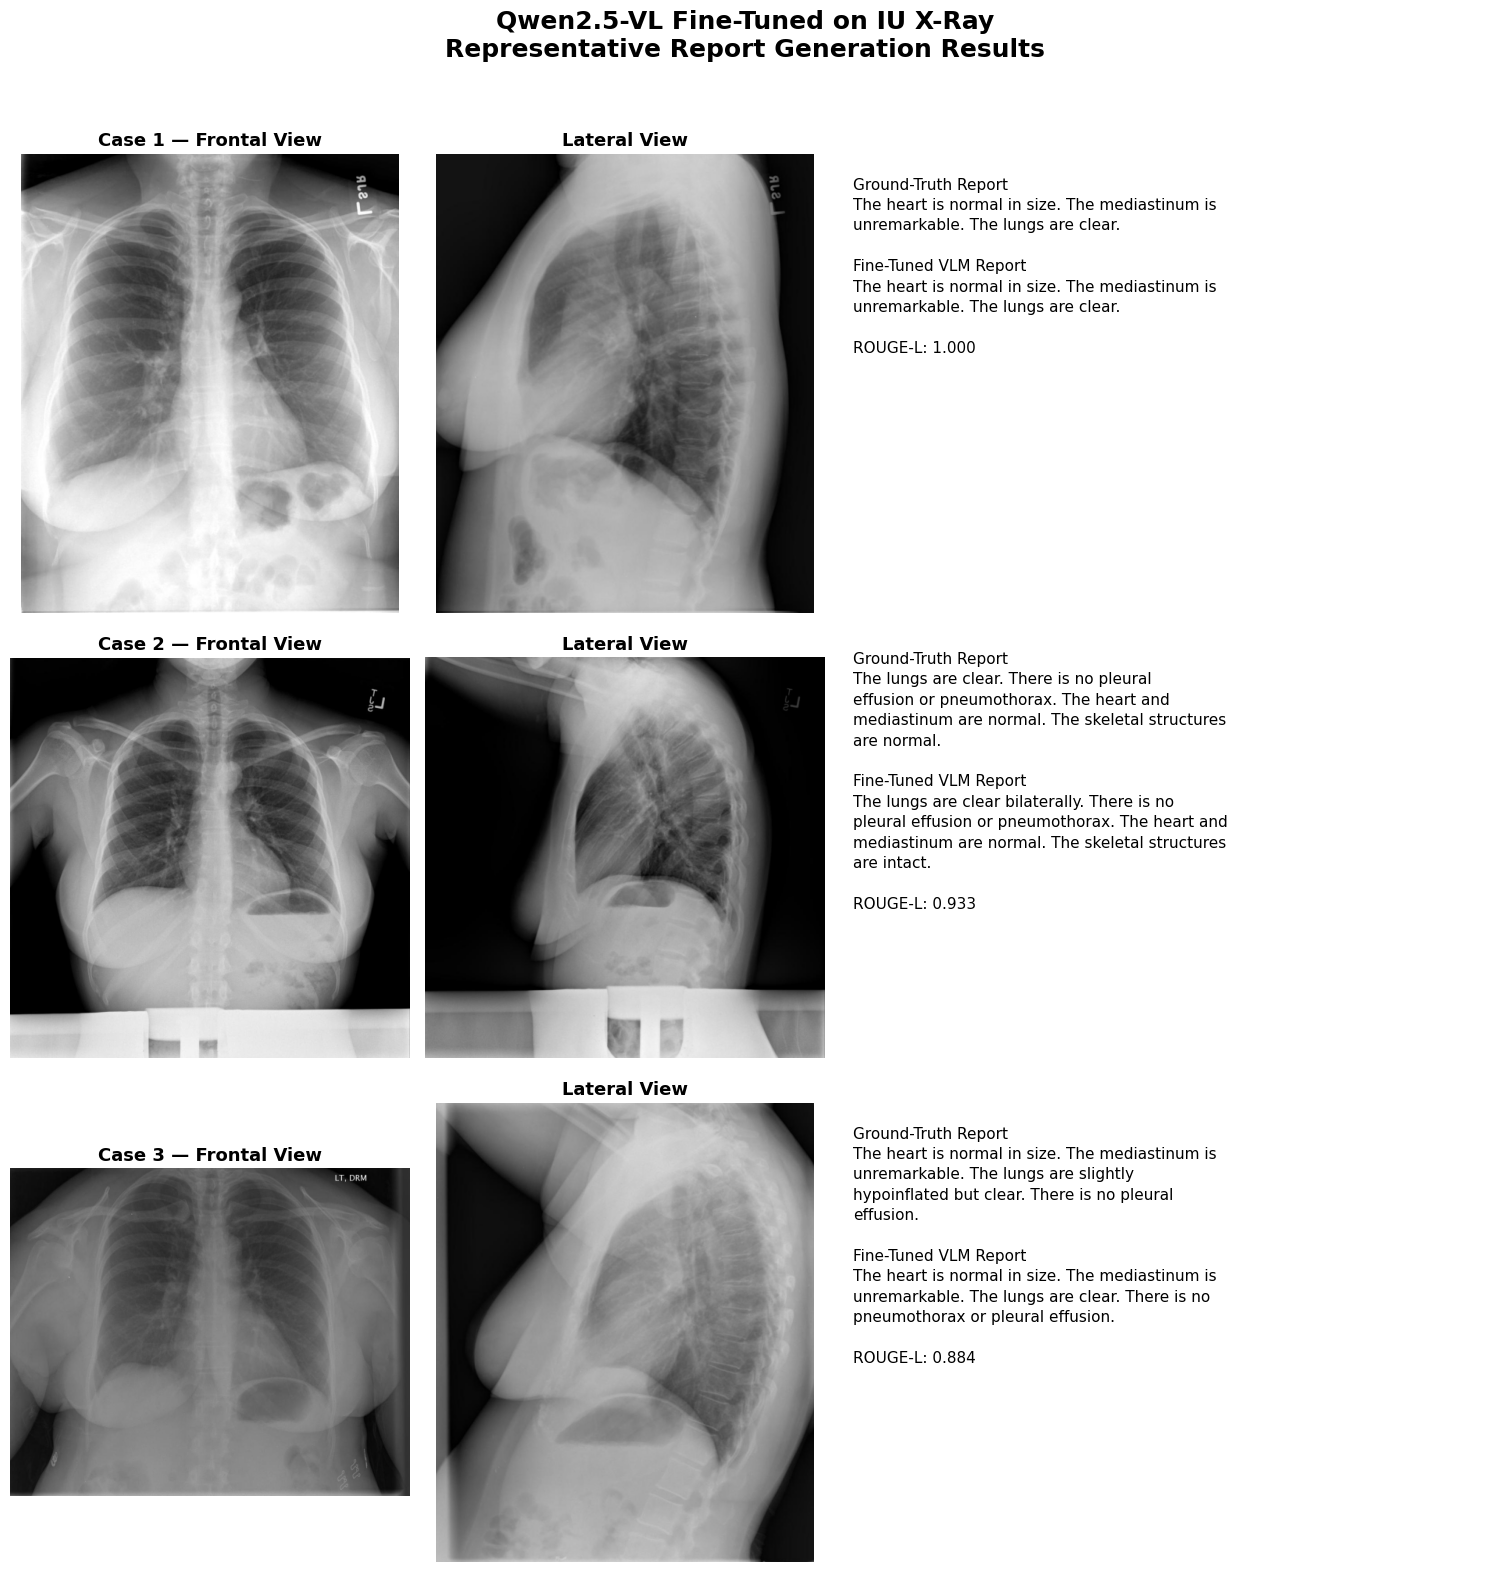

Saved: /kaggle/working/combined_vlm_results.png


In [33]:
import matplotlib.pyplot as plt
import textwrap

selected_ids = [
    "IU-Xray/00000036",
    "IU-Xray/00000405",
    "IU-Xray/00000356"
]

test_lookup = {sample["id"]: sample for sample in dataset["test"]}

fig, axes = plt.subplots(
    3, 3,
    figsize=(15, 16),
    gridspec_kw={"width_ratios": [1, 1, 1.6]}
)

for i, case_id in enumerate(selected_ids):

    sample = test_lookup[case_id]
    row = results_df[results_df["id"] == case_id].iloc[0]

    # Frontal X-ray
    axes[i, 0].imshow(sample["images"][0], cmap="gray")
    axes[i, 0].set_title(
        f"Case {i+1} — Frontal View",
        fontsize=13,
        fontweight="bold"
    )
    axes[i, 0].axis("off")

    # Lateral X-ray
    axes[i, 1].imshow(sample["images"][1], cmap="gray")
    axes[i, 1].set_title(
        "Lateral View",
        fontsize=13,
        fontweight="bold"
    )
    axes[i, 1].axis("off")

    # Reports
    axes[i, 2].axis("off")

    gt = "\n".join(
        textwrap.wrap(row["ground_truth"], width=48)
    )

    pred = "\n".join(
        textwrap.wrap(row["fine_tuned_report"], width=48)
    )

    text = (
        f"Ground-Truth Report\n"
        f"{gt}\n\n"
        f"Fine-Tuned VLM Report\n"
        f"{pred}\n\n"
        f"ROUGE-L: {row['rougeL']:.3f}"
    )

    axes[i, 2].text(
        0.02,
        0.95,
        text,
        va="top",
        fontsize=11,
        linespacing=1.45
    )

fig.suptitle(
    "Qwen2.5-VL Fine-Tuned on IU X-Ray\n"
    "Representative Report Generation Results",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

save_path = "/kaggle/working/combined_vlm_results.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", save_path)